In [ ]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Notez: Classifier, pas Regressor
from sklearn.metrics import classification_report, confusion_matrix
from parametrage import tune_and_evaluate 
from scratch_supervised import RandomForestScratch



In [19]:
df = pd.read_csv('../merged_datasets/MERGED_FINAL.csv')
df.head()

,spring_prec,autumn_prec,winter_prec,summer_prec,autumn_tmax,elevation,autumn_tmin,summer_tmax,spring_tmax,winter_tmin,...,GRIDCODE_14.0,COARSE,GRIDCODE_130.0,BSAT,GRIDCODE_151.0,GRIDCODE_201.0,GRIDCODE_110.0,ELEC_COND,GRIDCODE_200.0,fire_count
0,2.961474,1.542345,0.564423,0.628049,-0.923077,0.622003,-1.25,-0.5,-0.666667,-1.333333,...,False,-0.615385,False,-0.090909,False,True,False,1.0,False,1.0
1,2.961474,1.542345,0.564423,0.628049,-0.923077,0.622003,-1.25,-0.5,-0.666667,-1.333333,...,False,0.538462,False,-1.590909,False,True,False,0.0,False,1.0
2,2.961474,1.542345,0.564423,0.628049,-0.923077,0.622003,-1.25,-0.5,-0.666667,-1.333333,...,False,0.076923,False,0.045455,False,True,False,0.0,False,1.0
3,2.961474,1.542345,0.564423,0.628049,-0.923077,0.622003,-1.25,-0.5,-0.666667,-1.333333,...,False,0.384615,False,0.045455,False,True,False,13.0,False,1.0
4,-0.251256,-0.358306,0.002885,1.256098,-0.461538,0.631876,-0.75,0.0,0.333333,-0.800000,...,False,-0.615385,False,-0.090909,False,True,False,1.0,False,0.0


In [20]:
# 1. Préparation (comme avant)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop('fire_count', axis=1)

# --- TRANSFORMATION EN CLASSIFICATION ---
# Si fire_count > 0, alors 1 (Feu), sinon 0 (Pas de feu)
y = (df['fire_count'] > 0).astype(int)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Note: 'stratify=y' assure qu'il y a la même proportion de feux dans le train et le test




In [21]:
train_df = X_train.copy()
train_df[y.name] = y_train  # On ajoute la colonne cible

test_df = X_test.copy()
test_df[y.name] = y_test    # On ajoute la colonne cible

# 4. Affichage pour vérification
print("--- Aperçu du DataFrame d'entraînement (train_df) ---")
print(f"Dimensions : {train_df.shape}")
print(train_df.head())

print("\n--- Aperçu du DataFrame de test (test_df) ---")
print(f"Dimensions : {test_df.shape}")
print(test_df.head())

--- Aperçu du DataFrame d'entraînement (train_df) ---
Dimensions : (169191, 40)
        spring_prec  autumn_prec  winter_prec  summer_prec  autumn_tmax  \
191677     1.971524     2.791531     1.551923    -0.865854     0.615385   
48547     -0.144053    -0.195440    -0.340385     1.292683    -0.307692   
38618     -0.452261    -0.039088    -0.416346    -0.762195     1.230769   
69315     -0.145729    -0.084691    -0.277885    -0.243902     0.615385   
112037     0.224456    -0.184039     0.259615     0.219512    -0.153846   

        elevation  autumn_tmin  summer_tmax  spring_tmax  winter_tmin  ...  \
191677  -0.767278       0.5000     0.500000     0.000000     0.000000  ...   
48547    0.571227      -0.4375     0.166667     0.000000    -0.466667  ...   
38618   -0.441467       0.7500     1.166667     1.333333     0.266667  ...   
69315    0.018336       0.3750     0.250000     0.333333     0.000000  ...   
112037   0.328632      -0.2500     0.083333    -0.333333    -0.200000  ...   



In [22]:

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

print("\n================= 🌳 GRID SEARCH: Random Forest =================\n")
rf_results = tune_and_evaluate(
    balanced_train_df=train_df,
    test_df=test_df,
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    target_col="fire_count",
    cv_folds=5,
    scoring="recall",
    )



================= 🌳 GRID SEARCH: Random Forest =================


...GridSearchCV...


Nolbres de combinations: 108

Combination Num_1/108
Params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
-----------------------------------
Metriques de la Cross-validation :
   • accuracy: 0.9864 
   • precision: 0.9897 
   • recall: 0.9274 
   • f1: 0.9575 
   • roc_auc: 0.9895
-----------------------------------

Combination Num_2/108
Params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
-----------------------------------
Metriques de la Cross-validation :
   • accuracy: 0.9867 
   • precision: 0.9909 
   • recall: 0.9285 
   • f1: 0.9587 
   • roc_auc: 0.9898
-----------------------------------

Combination Num_3/108
Params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
-----------------------------------
Metriques de la Cross-validation :
   • accuracy: 0.986

In [23]:

# 3. Entraînement avec ÉQUILIBRAGE
# Le paramètre class_weight='balanced' ajuste automatiquement les poids
rf_model = RandomForestClassifier(n_estimators=50, min_samples_split=2, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 4. Évaluation
y_pred = rf_model.predict(X_test)

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Matrice de confusion :
[[35145   140]
 [  356  6657]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     35285
           1       0.98      0.95      0.96      7013

    accuracy                           0.99     42298
   macro avg       0.98      0.97      0.98     42298
weighted avg       0.99      0.99      0.99     42298



C:\Users\MELISSA\AppData\Local\Temp\ipykernel_21216\128492051.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp, y=feature_imp.index, palette="viridis")


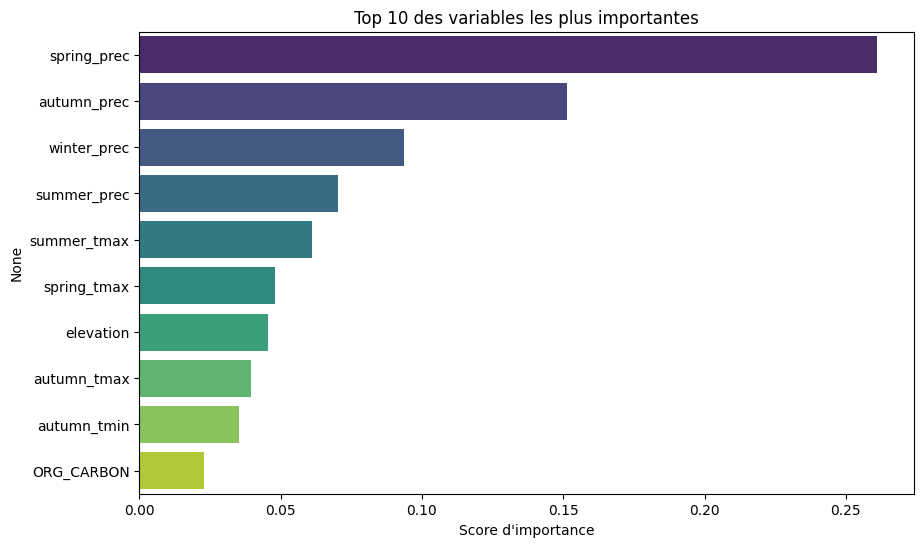

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Récupération des importances
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

# Affichage graphique
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp, y=feature_imp.index, palette="viridis")
plt.title("Top 10 des variables les plus importantes")
plt.xlabel("Score d'importance")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print(classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9885573785994609
Precision: 0.9802854200382521
Recall: 0.9500926850135463
F1: 0.9649529326574946
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     35285
           1       0.98      0.95      0.96      7013

    accuracy                           0.99     42298
   macro avg       0.99      0.97      0.98     42298
weighted avg       0.99      0.99      0.99     42298


Confusion Matrix:
[[35151   134]
 [  350  6663]]


In [ ]:
import pandas as pd
import numpy as np
from scratch import RandomForestScratch
import time

# 1. Fixer l'aléatoire pour la reproductibilité (comme random_state=42)
np.random.seed(42)

# 2. Chargement des données
print("Chargement des données...")
X_train = pd.read_csv('../merged_datasets/X_train_bal.csv').values
y_train = pd.read_csv('../merged_datasets/y_train_bal.csv').values.ravel() # .ravel() pour aplatir
X_test = pd.read_csv('../merged_datasets/X_test.csv').values
y_test = pd.read_csv('../merged_datasets/y_test.csv').values.ravel()

# 3. Initialisation avec les paramètres proches de Sklearn
print("Initialisation du modèle...")
rf = RandomForestScratch(
    n_trees=50,            # Comme n_estimators=50
    max_depth=20,           # Assez profond pour imiter Sklearn
    min_samples_split=10,    # Défaut Sklearn
)

# 4. Entraînement (avec mesure du temps)
start_time = time.time()
print(f"Début de l'entraînement de {rf.n_trees} arbres sur {len(X_train)} lignes.")
print("Cela peut être long, prenez un café... ☕")

rf.fit(X_train, y_train)

end_time = time.time()
print(f"Entraînement terminé en {(end_time - start_time)/60:.2f} minutes.")

# 5. Prédiction
print("Calcul des prédictions...")
y_pred = rf.predict(X_test)

# 6. Calcul des Métriques (Accuracy & Recall)
# Accuracy
accuracy = np.mean(y_test == y_pred)

# Recall (Calcul manuel : TP / (TP + FN))
tp = np.sum((y_test == 1) & (y_pred == 1))
fn = np.sum((y_test == 1) & (y_pred == 0))
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print("-" * 30)
print("RÉSULTATS DU MODÈLE FROM SCRATCH")
print("-" * 30)
print(f"Accuracy : {accuracy:.4f} (ou {accuracy*100:.2f}%)")
print(f"Recall   : {recall:.4f}   (ou {recall*100:.2f}%)")
print("-" * 30)

# Matrice de confusion simple
tn = np.sum((y_test == 0) & (y_pred == 0))
fp = np.sum((y_test == 0) & (y_pred == 1))
print(f"Matrice :\n[[{tn}  {fp}]\n [{fn}   {tp}]]")

Chargement des données...
Initialisation du modèle...
Début de l'entraînement de 50 arbres sur 158283 lignes.
Cela peut être long, prenez un café... ☕
Arbre 1/50 entraîné.
Arbre 2/50 entraîné.
Arbre 3/50 entraîné.
Arbre 4/50 entraîné.
Arbre 5/50 entraîné.
Arbre 6/50 entraîné.
Arbre 7/50 entraîné.
Arbre 8/50 entraîné.
Arbre 9/50 entraîné.
Arbre 10/50 entraîné.
Arbre 11/50 entraîné.
Arbre 12/50 entraîné.


In [ ]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print(classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Recall (Sklearn) : 0.9415
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     35285
         1.0       0.99      0.94      0.97      7013

    accuracy                           0.99     42298
   macro avg       0.99      0.97      0.98     42298
weighted avg       0.99      0.99      0.99     42298

